In [29]:
# LE VARIABILI GLOBALI CHE DEVONO ESSERE USATE:
# NOME DELLE CARTELLE DA USARE NELL'ORGANIZZAZIONE DEL DATASET:
import os
A_FOLDER= 'Longitudinal_Studies'
S_FOLDER= 'Super_Resolution'
P_FOLDER = 'Mosaicing'
TEST_FOLDER= 'Test'
REFERENCE_FOLDER= 'Reference'
NUM_WORKERS = os.cpu_count() # to define the num of subprocesses to use for dataloader



# Download the data
url = https://projects.ics.forth.gr/cvrl/fire/FIRE.7z
path_to_zip_file = ''

In [2]:
import os
from pathlib import Path
import py7zip
import requests
from rich.console import Console
from typing import Iterator
from contextlib import contextmanager

url_fire_dataset = 'https://projects.ics.forth.gr/cvrl/fire/FIRE.7z'

#zip_request = requests.get(url_fire_dataset)

@contextmanager
def Loading(
    message: str,
) -> Iterator[None]:
    """
    Implement loading animation.

    Parameters
    ----------
    message : str
        The text to print during the animation.

    Returns
    -------
    None

    """
    console = Console()
    try:
        with console.status(f"[bold green]{message}..."):
            yield
    finally:
        console.log(f"[bold green]{message}... Done")


In [3]:
def walk_through_dir(dir_path):
  """
  Walks through dir_path returning its contents.
  Args:
    dir_path (str or pathlib.Path): target directory
  
  Returns:
    A print out of:
      number of subdiretories in dir_path
      number of images (files) in each subdirectory
      name of each subdirectory
  """
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} files in '{dirpath}'.")
 
    

In [4]:
import py7zip
import py7zip.py7zip


fire_path = Path(os.getcwd()).resolve().parent / 'Modules' / 'dataset'
zip_path = fire_path / 'FIRE.7z'
if not fire_path.is_dir():
    os.makedirs(fire_path, exist_ok=True)
else:
    print('the dataser folder already exists')

zip_manager = py7zip.py7zip.Py7zip()

the dataser folder already exists


with Loading('Downloading FIRE dataset'):
    with open(zip_path, 'wb') as f:
        zip_request = requests.get(url_fire_dataset)
        f.write(zip_request.content)
        
destination = fire_path 
source = zip_path
with Loading('Decompressing FIRE dataset'):
    zip_manager.decompress(src = zip_path, dest = fire_path)
    

In [5]:
import os
import py7zr
import requests
import zipfile
from pathlib import Path


def get_dataset(
        dataset_url: str,
        destination_path: Path,
        dataset_name: str = '',
        remove_zip: bool = False
) -> None:
    """
    Download a dataset from a given url and decompress it in a given destination path.

    Parameters
    ----------
    dataset_url : str
        The url of the dataset to download.
    destination_path: Path
        The path where the dataset will be decompressed.
    dataset_name : str, optional
        The name of the dataset file to download.
    remove_zip : bool, optional
        Whether to remove the zip file after decompression.
    """
    if dataset_name == '':
        dataset_name = Path(dataset_url).name

    # Create the destination folder if it does not exist
    if destination_path.is_dir():
        print(f'The {destination_path} folder already exists')
    else:
        os.makedirs(destination_path, exist_ok=True)

    # Control if the dataset_name is present in the folders list of destination_path
    dataset_file = destination_path / dataset_name

    for _, folders, _ in os.walk(destination_path):
        for fold in folders:
            if dataset_name.upper() == fold.upper():
                print(f'[INFO] The {dataset_name} dataset is already extracted in the {destination_path} folder\nNo need to extract it again')
                return None

    # Download and save the dataset from the given url
    if dataset_file.exists():
        print(f'[INFO] {dataset_name} already exists, no need to download it again')
    else:
        zip_request = requests.get(dataset_url)
        with open(dataset_file, 'wb') as f:
            f.write(zip_request.content)

    # Decompress the dataset if not already done
    if dataset_file.suffix == '.7z':
        with py7zr.SevenZipFile(dataset_file, mode='r') as archive:
            archive.extractall(path=destination_path)
    elif dataset_file.suffix == '.zip':
        with zipfile.ZipFile(dataset_file, 'r') as archive:
            archive.extractall(path=destination_path)
    else:
        print(f'[ERROR] Unsupported archive format: {dataset_file.suffix}')
        return None

    if remove_zip:
        os.remove(dataset_file)

    print(f'[INFO] {dataset_name} has been successfully downloaded and extracted to {destination_path}')
    return None

In [6]:
#get_dataset(dataset_url = url_fire_dataset, destination_path = fire_path, dataset_zip = 'FIRE.7z', remove_zip = True)
fire_zip = fire_path / 'FIRE.7z'

get_dataset(dataset_url='https://projects.ics.forth.gr/cvrl/fire/FIRE.7z', 
            destination_path=fire_path,
            remove_zip=False)

The C:\Users\gioco\Desktop\GITHUB_MAIN_FOLDER\ImRegODE\Main_Folder\Modules\dataset folder already exists
[INFO] FIRE.7z already exists, no need to download it again
[INFO] FIRE.7z has been successfully downloaded and extracted to C:\Users\gioco\Desktop\GITHUB_MAIN_FOLDER\ImRegODE\Main_Folder\Modules\dataset


## Categorization Test images - Reference images

In [7]:
import os
import shutil

def organize_folder(parent_folder : Path, # the path folder to organize
                                    categories : list[str], # name of the folders
                                     folder_names: list[str] = []): # the categories of daughter folders
    # aggiungi un file.suffix per il tipo di file da organizzare e spostare nella cartella
    '''given a certain parent dir it reorganize the files respecting the categories:

    assure to give the respective order between the folder name and the categories if given
    EXAMPLE: 
        folder_names = ['truth', 'fake']
        categories ['_1', '_2']
        if _1 corresponds to truth folder
    '''
    if not len(categories):
        print('[ERROR] the categories must be given')
        return 
    
    
    # get the list of files in parent folder
    files = [f for f in parent_folder.glob('*') if f.is_file()]
    if not len(files):
        print(f'[ERROR] there are no files in {parent_folder}')
    # control if categories are indentifiable
    absent_cat =[]
    for cat in categories:
        cat_not_in = False
        for file in files:
            if cat in file.name:
                cat_not_in = True
                break
        if not cat_not_in :
            absent_cat.append(cat)
    for cat in set(absent_cat):
        print(f'[ERROR] the category {cat} is not identifiable in the files')
            
        
    # control if folder names is given:
    if not len(folder_names):
        folder_names = categories
    
    for daughter_folder in folder_names:
        # create the folder if it does not exist
        daughter_folder_path = parent_folder / daughter_folder
        
        if not daughter_folder_path.is_dir():
            os.makedirs(daughter_folder_path, exist_ok=True)
        
        #then move the file if the type of category is in
    path_cat_dict = {k.upper() :v for k , v in zip(categories, folder_names)}

    for file in files:
        cat = file.name[0].upper()
        new_folder = parent_folder / path_cat_dict[cat] / file.name #parent_folder / path_cat_dict[cat]
        shutil.move(src=str(file), dst=str(new_folder))


   
                


In [164]:
image_type = ['Reference','Test']
categories = ['_1', '_2']
fire_images_path = Path.cwd().parent / 'Modules' / 'dataset' / 'FIRE' / 'Images'
organize_folder(parent_folder=fire_images_path, categories=categories, folder_names=image_type)

image_type = ['Longitudinal_Studies', 'Mosaicing', 'Super_Resolution']
categories = ['A', 'P', 'S']
reference_images_path = Path.cwd().parent / 'Modules' / 'dataset' / 'FIRE' / 'Images' / 'Reference'
organize_folder(parent_folder=reference_images_path, categories=categories, folder_names=image_type)
test_images_path =Path.cwd().parent / 'Modules' / 'dataset' / 'FIRE' / 'Images' / 'Test'
organize_folder(parent_folder=test_images_path, categories=categories, folder_names=image_type)


[ERROR] there are no files in c:\Users\gioco\Desktop\GITHUB_MAIN_FOLDER\ImRegODE\Main_Folder\Modules\dataset\FIRE\Images
[ERROR] the category _1 is not identifiable in the files
[ERROR] the category _2 is not identifiable in the files


## Creation of the DATASET

In [252]:
# generate a file path as sample to test all the sequent code:
example_path = Path.cwd().parent / 'Modules' / 'dataset' / 'FIRE' / 'Images' 
list_images = list(example_path.glob('*/*/*.jpg'))
example_image_path = list_images[0]
example_image_path

WindowsPath('c:/Users/gioco/Desktop/GITHUB_MAIN_FOLDER/ImRegODE/Main_Folder/Modules/dataset/FIRE/Images/Reference/Longitudinal_Studies/A01_1.jpg')

In [8]:
def get_dirs_of(file_path : Path,
                 
                )->list[str]:
    '''
    given a certain path it get all the dir as a list of str to get this image
    '''
    if not file_path.is_file():
        image_type, image_deformation = file_path.parts[-2:]
        return [image_type, image_deformation]
        
    image_type, image_deformation, file_name =  file_path.parts[-3:]
    return [image_type, image_deformation, file_name]


In [138]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from typing import Tuple, List
import random
import os
from pathlib import Path

class SimpleImRegDataSet(Dataset):
    def __init__(self, 
                 dataset_folder_path: Path,
                 reference_folder_name: str | Path,
                 test_folder_name: str | Path,
                 transforms=None) -> None:
        self.dataset_folder_path = dataset_folder_path
        self.reference_folder_name = reference_folder_name
        self.test_folder_name = test_folder_name
        self.transforms = transforms
        self.test_images = list(self.dataset_folder_path.glob(f'Images/{self.test_folder_name}/*/*'))
        self.reference_images = list(self.dataset_folder_path.glob(f'Images/{self.reference_folder_name}/*/*'))

    def __len__(self) -> int:
        tot_images = len(self.test_images) + len(self.reference_images)
        return tot_images

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, torch.Tensor]:
        if index not in range(0, len(self.test_images)):
            print(f'[WARNING] - unable to get the {index} image, another one casually get from the dirs')
            index = random.randint(0, len(self.test_images) - 1)
        
        test_image = Image.open(self.test_images[index])
        reference_image = Image.open(self.reference_images[index])
        test_image_name = self.test_images[index].stem
        reference_image_name = self.reference_images[index].stem
        
        if self.transforms:
            test_image = self.transforms(test_image)
            reference_image = self.transforms(reference_image)
        
        return test_image, reference_image, test_image_name, reference_image_name
    
fire_dataset_path= Path.cwd().parent / 'Modules' / 'dataset' / 'FIRE' 
transform_tensor = transforms.Compose([transforms.ToTensor()])
dataset = SimpleImRegDataSet(dataset_folder_path=fire_dataset_path, reference_folder_name='Reference', test_folder_name='Test', transforms=transform_tensor)

# Creare il dataloader
dataloader = DataLoader(dataset, batch_size=1, shuffle=False)



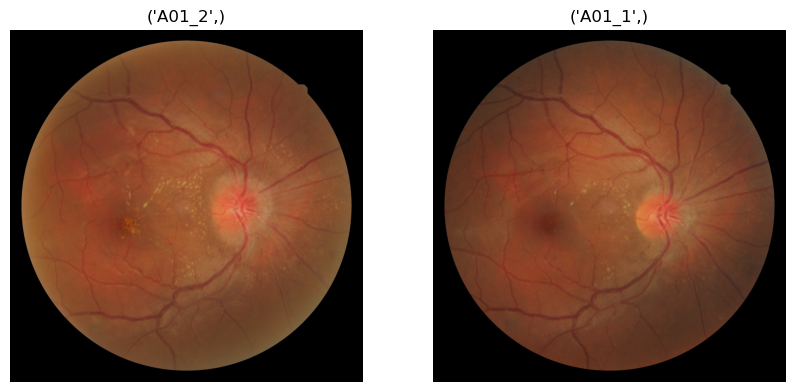

In [159]:
import matplotlib.pyplot as plt
import numpy as np
iter_dataloader = iter(dataloader)
first_batch = next(iter_dataloader)
second_batch = next(iter_dataloader)
third_batch = next(iter_dataloader)
img_ref, img_test, test_image_name, reference_image_name = first_batch



def show_image(test_image : torch.Tensor,
               reference_image: torch.Tensor,
               test_image_name: str,
               reference_image_name: str
               )->None:
    #reference_image, test_image, test_image_name, reference_image_name = batch in case to use the dataloader itself
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(test_image.squeeze().permute(1,2,0).numpy())
    ax[0].set_title(f'{test_image_name}')
    ax[0].axis('off')
    ax[1].imshow(reference_image.squeeze().permute(1,2,0).numpy())
    ax[1].set_title(f'{reference_image_name}')
    ax[1].axis('off')
    plt.show()

show_image(test_image=img_test, reference_image=img_ref, test_image_name=test_image_name, reference_image_name=reference_image_name)

    

In [165]:
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms
from typing import Tuple, Dict, List
import torch
import random
import os
from pathlib import Path

class ImageRegistrationCustom(Dataset):
    def __init__(self,
                dataset_folder_path: Path, # the path of FIRE dataset: Path.cwd().parent / 'Modules' / 'dataset' / 'FIRE'
                transform=None, 
                target_transform=None)->None:
        self.dataset_path = dataset_folder_path
        path_to_image_types = dataset_folder_path / 'Images' 
        path_to_deformation_types = dataset_folder_path /  'Images' / 'Test' 
        self.reference_images_paths = list(dataset_folder_path.glob('Images/Reference/*/*.jpg'))
        self.test_images_paths = list(dataset_folder_path.glob('Images/Test/*/*.jpg'))
        self.transform = transform # da trasformare le singole immagini? 
        self.target_transform = target_transform
        self.image_types = [d.name for d in path_to_image_types.iterdir() if d.is_dir()]
        self.deformation_types = [d.name  for d in path_to_deformation_types.iterdir() if d.is_dir()]

    # costruisci un dict  per abbreviare long... super res e mosaicing in A, S, P ... ?
    def load_image(self, 
                   index : str | int = 'random', # valuta la possibilità di mettere il random in una funzione a parte
                   deformation: str= '') ->Image.Image: # given an index it get an image
        ''' 
        depending the type there are different possibilities
        depending which type f deformation to visualize
        ****aggiungi la possibilità di usare una trasformazione su un'immagine di test 
        '''
        images = list(self.dataset_path.glob('*/*/*/*'))
        
        if deformation == '':
            images = list(self.dataset_path.glob('*/*/*/*'))
        else:
            if deformation not in self.deformation_types:
                print(f'to see possibile selection use the method .deformation_types')
                raise ValueError(f"Deformation type {deformation} not found in the dataset")
            else:
                images = list(self.dataset_path.glob(f'*/*/*/{deformation}/*'))
        
        if index.lower() == 'random' or not isinstance(index, int):
            idx = random.randint(0, len(images)-1)
        elif isinstance(index, int):
            idx=index
            if index not in range(0, len(images)):
                print(f'[WARNING] - unable to get the {index} image, another one casually get from the dirs')
                idx = random.randint(0, len(images) - 1)
                images = list(self.dataset_path.glob('*/*/*/*')) 
        
        return Image.open(images[idx])      # aggiusta in una tupla 
        

    def __len__(self,
                info : bool = True):
        '''show the distribution of sample in the dataset path
        then the number of total files in the deepest folder'''
        if info:
            for dirpath, dirnames, filenames in os.walk(self.dataset_path):
                print(f"[INFO] - There are {len(dirnames)} directories and {len(filenames)} files in '{dirpath}'.")
        return len(list(self.dataset_path.glob('*/*/*/*')))
    
    def get_coupled_imgs(self,
                    index: bool|int = False,
                    deformation_choice : str = '' 
                    ) -> Tuple[torch.Tensor, torch.Tensor, str]:
        '''get the image pairs from the list of avaiable '''
        if deformation_choice == '' or deformation_choice not in self.deformation_types:
            test_images = list(self.dataset_path.glob('*/Test/*/*'))
            reference_images = list(self.dataset_path.glob('*/Reference/*/*'))
            print('[WARNING] - not a valid choice of deformation, use of the entire dataset as batch') 
        else: 
            test_images = list(self.dataset_path.glob(f'*/*/Test/{deformation_choice}/*'))
            reference_images = list(self.dataset_path.glob(f'Images/Reference/{deformation_choice}/*.jpg'))
        if not index or index not in range(0, len(test_images)):
            index = random.randint(0, len(test_images)-1)
            
        test_image = test_images[index]
        reference_image = reference_images[index]
        test_reference,deformation, filename = get_dirs_of(test_image)
        print(f'the selected/chosen image is {filename}, from {deformation} folder of {test_reference}')
        if self.transform:
            reference_image = self.transform(Image.open(reference_image))  
        if self.target_transform:
            test_image = self.target_transform(Image.open(test_image))
        return test_image, reference_image, deformation

    def __getitem__(self, 
                    index : bool|int = False,
                    deformation_choice: str = ''):
        ''' get the images couple of reference/test as tensor tuple'''
        test_image, reference_image, _ = self.get_coupled_imgs(index=index, deformation_choice=deformation_choice)
        if self.transform:
            test_image = self.transform(test_image)
        if self.target_transform:
            reference_image = self.target_transform(reference_image)
        return test_image, reference_image 
            
        

In [169]:
fire_dataset_path = Path.cwd().parent / 'Modules' /'dataset'/'FIRE'

imreg_dataset = ImageRegistrationCustom(dataset_folder_path=fire_dataset_path)
img= imreg_dataset.load_image(deformation='', index='random')

test_img, reference_img, deformation = imreg_dataset.get_coupled_imgs()


[WARNING] - not a valid choice of deformation, use of the entire dataset as batch
the selected/chosen image is S43_2.jpg, from Super_Resolution folder of Test


In [170]:
import matplotlib.pyplot as plt
import numpy as np

img_t = Image.open(test_img)
img_r = Image.open(reference_img)
image_to_plot = np.asarray(img_t)
img_t, img_r

(<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=2912x2912>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=2912x2912>)

## Preprocess the image from the dataloader for the nn

16

## Create a funcion to display images random or defined 

WindowsPath('c:/Users/gioco/Desktop/GITHUB_MAIN_FOLDER/ImRegODE/Main_Folder/Modules/dataset/FIRE/Images/Reference/Mosaicing/P32_1.jpg')